In [1]:
import json
import matplotlib.pyplot as plt

# Terminals
In this experiment, I tested how different numbers of terminals affect the performance of database.
By default, for TPC-C benchmark 10 terminals are advised.
All other parameters were set to default.

## Parse SSD results

In [2]:
with open('data/results_ssd_term.jsonl', 'r', encoding='utf-8') as f:
    ssd_json = json.load(f)

ssd_tp = []
ssd_gtp = []
ssd_terms = []
ssd_dist = []

for entry in ssd_json:
    ssd_tp.append(entry['Throughput (requests/second)'])
    ssd_gtp.append(entry['Goodput (requests/second)'])
    ssd_terms.append(entry['terminals'])
    ssd_dist.append({
        'med': entry['Latency Distribution']['Median Latency (microseconds)'],
        'q1': entry['Latency Distribution']['25th Percentile Latency (microseconds)'],
        'q3': entry['Latency Distribution']['75th Percentile Latency (microseconds)'],
        'whislo': entry['Latency Distribution']['Minimum Latency (microseconds)'],
        'whishi': entry['Latency Distribution']['Maximum Latency (microseconds)'],
        'mean': entry['Latency Distribution']['Average Latency (microseconds)'],
    })

## Parse HDD results

In [3]:
with open('data/results_hdd_term.jsonl', 'r', encoding='utf-8') as f:
    hdd_json = json.load(f)

hdd_tp = []
hdd_gtp = []
hdd_terms = []
hdd_dist = []

for entry in hdd_json:
    hdd_tp.append(entry['Throughput (requests/second)'])
    hdd_gtp.append(entry['Goodput (requests/second)'])
    hdd_terms.append(entry['terminals'])
    hdd_dist.append({
        'med': entry['Latency Distribution']['Median Latency (microseconds)'],
        'q1': entry['Latency Distribution']['25th Percentile Latency (microseconds)'],
        'q3': entry['Latency Distribution']['75th Percentile Latency (microseconds)'],
        'whislo': entry['Latency Distribution']['Minimum Latency (microseconds)'],
        'whishi': entry['Latency Distribution']['Maximum Latency (microseconds)'],
        'mean': entry['Latency Distribution']['Average Latency (microseconds)'],
    })

## General comparison

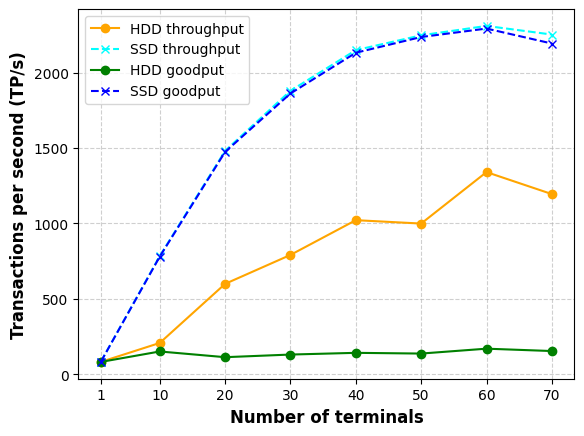

In [4]:
assert(hdd_terms == hdd_terms)

fig, ax = plt.subplots()
ax.grid(True, linestyle='--', alpha=0.6)

ax.plot(hdd_terms, hdd_tp, label='HDD throughput', color='orange', marker='o')
ax.plot(ssd_terms, ssd_tp, label='SSD throughput', color='cyan', linestyle='--', marker='x')
ax.plot(hdd_terms, hdd_gtp, label='HDD goodput', color='green', marker='o')
ax.plot(ssd_terms, ssd_gtp, label='SSD goodput', color='blue', linestyle='--', marker='x')

ax.set_xticks(ssd_terms)

ax.set_xlabel('Number of terminals', fontsize=12, fontweight='bold')
ax.set_ylabel('Transactions per second (TP/s)', fontsize=12, fontweight='bold')

ax.legend()
plt.show()

## Detailed SSD throughput vs goodput

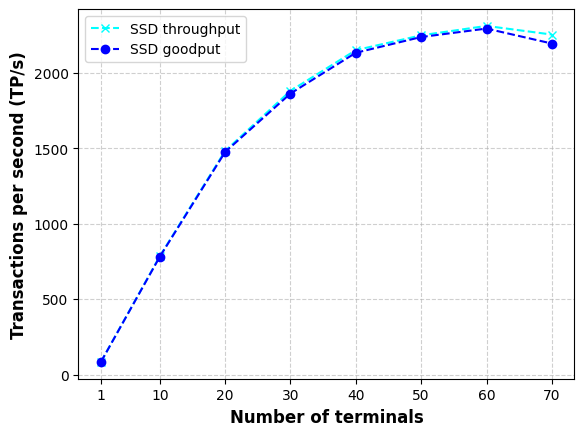

In [5]:
fig, ax = plt.subplots()
ax.grid(True, linestyle='--', alpha=0.6)

ax.plot(ssd_terms, ssd_tp, label='SSD throughput', color='cyan', linestyle='--', marker='x')
ax.plot(ssd_terms, ssd_gtp, label='SSD goodput', color='blue', linestyle='--', marker='o')

ax.set_xticks(ssd_terms)

ax.set_xlabel('Number of terminals', fontsize=12, fontweight='bold')
ax.set_ylabel('Transactions per second (TP/s)', fontsize=12, fontweight='bold')

ax.legend()
plt.show()

## Detailed HDD throughput vs goodput

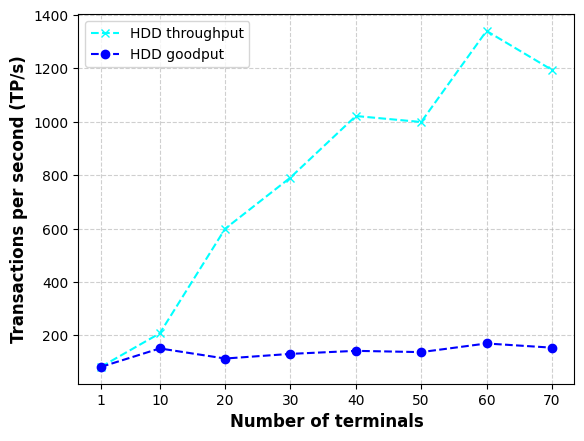

In [6]:
fig, ax = plt.subplots()
ax.grid(True, linestyle='--', alpha=0.6)

ax.plot(hdd_terms, hdd_tp, label='HDD throughput', color='cyan', linestyle='--', marker='x')
ax.plot(hdd_terms, hdd_gtp, label='HDD goodput', color='blue', linestyle='--', marker='o')

ax.set_xticks(hdd_terms)

ax.set_xlabel('Number of terminals', fontsize=12, fontweight='bold')
ax.set_ylabel('Transactions per second (TP/s)', fontsize=12, fontweight='bold')

ax.legend()
plt.show()

## SSD Latency distribution

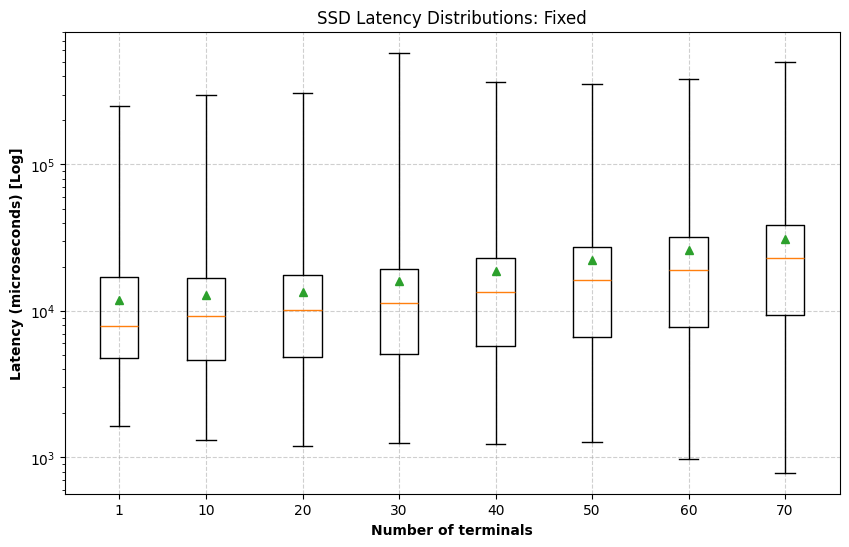

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bxp(ssd_dist, positions=ssd_terms, widths=4.0, showfliers=False, showmeans=True)

ax.set_yscale('log')
ax.grid(True, linestyle='--', alpha=0.6)

ax.set_ylabel('Latency (microseconds) [Log]', fontweight='bold')
ax.set_xlabel('Number of terminals', fontweight='bold')
ax.set_title('SSD Latency Distributions: Fixed')

plt.show()

## HDD Latency Distribution

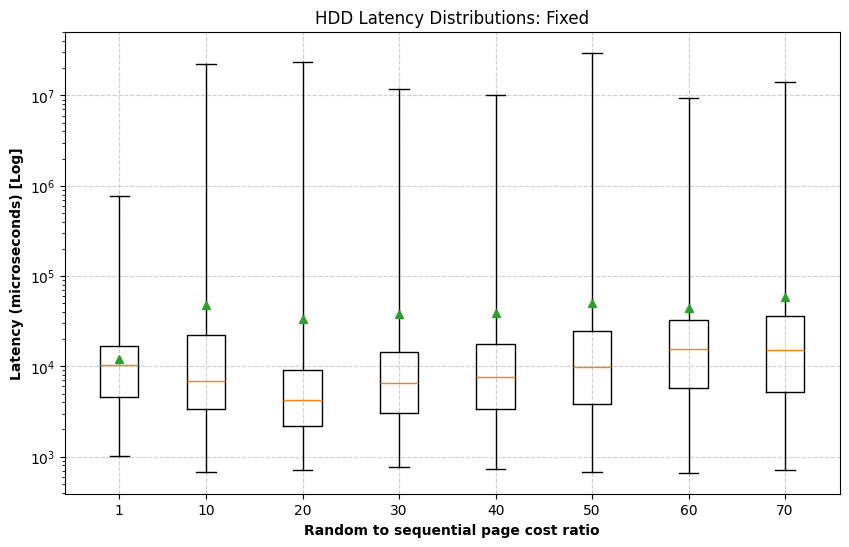

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bxp(hdd_dist, positions=hdd_terms, widths=4.0, showfliers=False, showmeans=True)

ax.set_yscale('log')
ax.grid(True, linestyle='--', alpha=0.6)

ax.set_ylabel('Latency (microseconds) [Log]', fontweight='bold')
ax.set_xlabel('Number of terminals', fontweight='bold')
ax.set_title('HDD Latency Distributions: Fixed')

plt.show()